# Klasyfikacja obiektów astronomicznych — SDSS17

Klasyfikacja wieloklasowa (GALAXY, QSO, STAR). Plik danych: `data/star_classification.csv`.

Import bibliotek i ustawienie stałych projektu. Ustalamy seed dla powtarzalności wyników treningu.


In [2]:
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)

TARGET_COLUMN = "class"
ID_COLUMNS = [
    "obj_ID", "spec_obj_ID", "run_ID", "rerun_ID",
    "cam_col", "field_ID", "plate", "MJD", "fiber_ID",
]
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

## 1. Analiza danych

Wczytanie zbioru SDSS17 z pliku CSV. Sprawdzamy rozmiar danych i pierwsze rekordy.


In [3]:
df = pd.read_csv(Path("data/star_classification.csv"))
display(df.head())
print(f"Rozmiar: {df.shape[0]:,} × {df.shape[1]}")

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


Rozmiar: 100,000 × 18


Analiza typów kolumn i brakujących wartości. Weryfikujemy, czy zbiór wymaga imputacji.


In [4]:
display(df.dtypes.to_frame(name="dtype"))

missing = df.isnull().sum()
missing_df = pd.DataFrame({"brakujące": missing, "procent_%": (missing / len(df) * 100).round(4)})
display(missing_df)
print(f"Łącznie braków: {missing.sum()}")

,dtype
obj_ID,float64
alpha,float64
delta,float64
u,float64
g,float64
r,float64
i,float64
z,float64
run_ID,int64
rerun_ID,int64


,brakujące,procent_%
obj_ID,0,0.0
alpha,0,0.0
delta,0,0.0
u,0,0.0
g,0,0.0
r,0,0.0
i,0,0.0
z,0,0.0
run_ID,0,0.0
rerun_ID,0,0.0


Łącznie braków: 0


Statystyki opisowe cech numerycznych — średnie, odchylenia i zakresy wartości.


In [5]:
df.info()
display(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7), str(1)
mem

,count,mean,std,min,25%,50%,75%,max
obj_ID,100000.0,1.237665e+18,8.438560e+12,1.237646e+18,1.237659e+18,1.237663e+18,1.237668e+18,1.237681e+18
alpha,100000.0,1.776291e+02,9.650224e+01,5.527828e-03,1.275182e+02,1.809007e+02,2.338950e+02,3.599998e+02
delta,100000.0,2.413530e+01,1.964467e+01,-1.878533e+01,5.146771e+00,2.364592e+01,3.990155e+01,8.300052e+01
u,100000.0,2.198047e+01,3.176929e+01,-9.999000e+03,2.035235e+01,2.217914e+01,2.368744e+01,3.278139e+01
g,100000.0,2.053139e+01,3.175029e+01,-9.999000e+03,1.896523e+01,2.109983e+01,2.212377e+01,3.160224e+01
r,100000.0,1.964576e+01,1.854760e+00,9.822070e+00,1.813583e+01,2.012529e+01,2.104478e+01,2.957186e+01
i,100000.0,1.908485e+01,1.757895e+00,9.469903e+00,1.773228e+01,1.940514e+01,2.039650e+01,3.214147e+01
z,100000.0,1.866881e+01,3.172815e+01,-9.999000e+03,1.746068e+01,1.900460e+01,1.992112e+01,2.938374e+01
run_ID,100000.0,4.481366e+03,1.964765e+03,1.090000e+02,3.187000e+03,4.188000e+03,5.326000e+03,8.162000e+03
rerun_ID,100000.0,3.010000e+02,0.000000e+00,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02,3.010000e+02


Rozkład klas docelowych: liczność i udział procentowy każdej kategorii (GALAXY, QSO, STAR).


,liczność,procent_%
class,,
GALAXY,59445,59.44
QSO,18961,18.96
STAR,21594,21.59


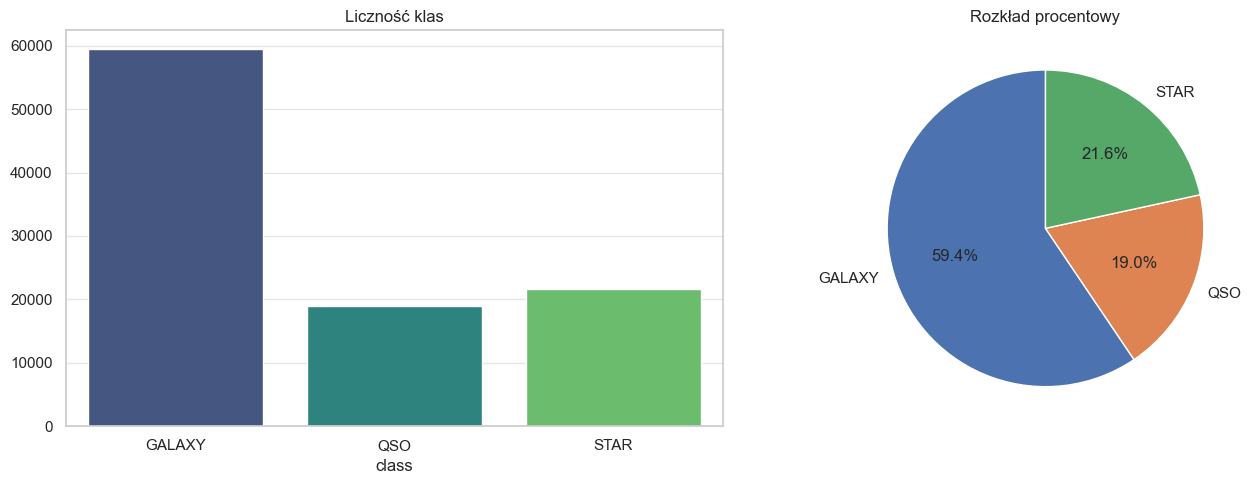

In [6]:
class_counts = df[TARGET_COLUMN].value_counts().sort_index()
class_summary = pd.DataFrame({
    "liczność": class_counts,
    "procent_%": (class_counts / len(df) * 100).round(2),
})
display(class_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index,
            palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Liczność klas")
axes[1].pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%", startangle=90)
axes[1].set_title("Rozkład procentowy")
plt.tight_layout()
plt.show()

Histogramy cech numerycznych pozwalają zobaczyć kształt rozkładów i wartości odstające.


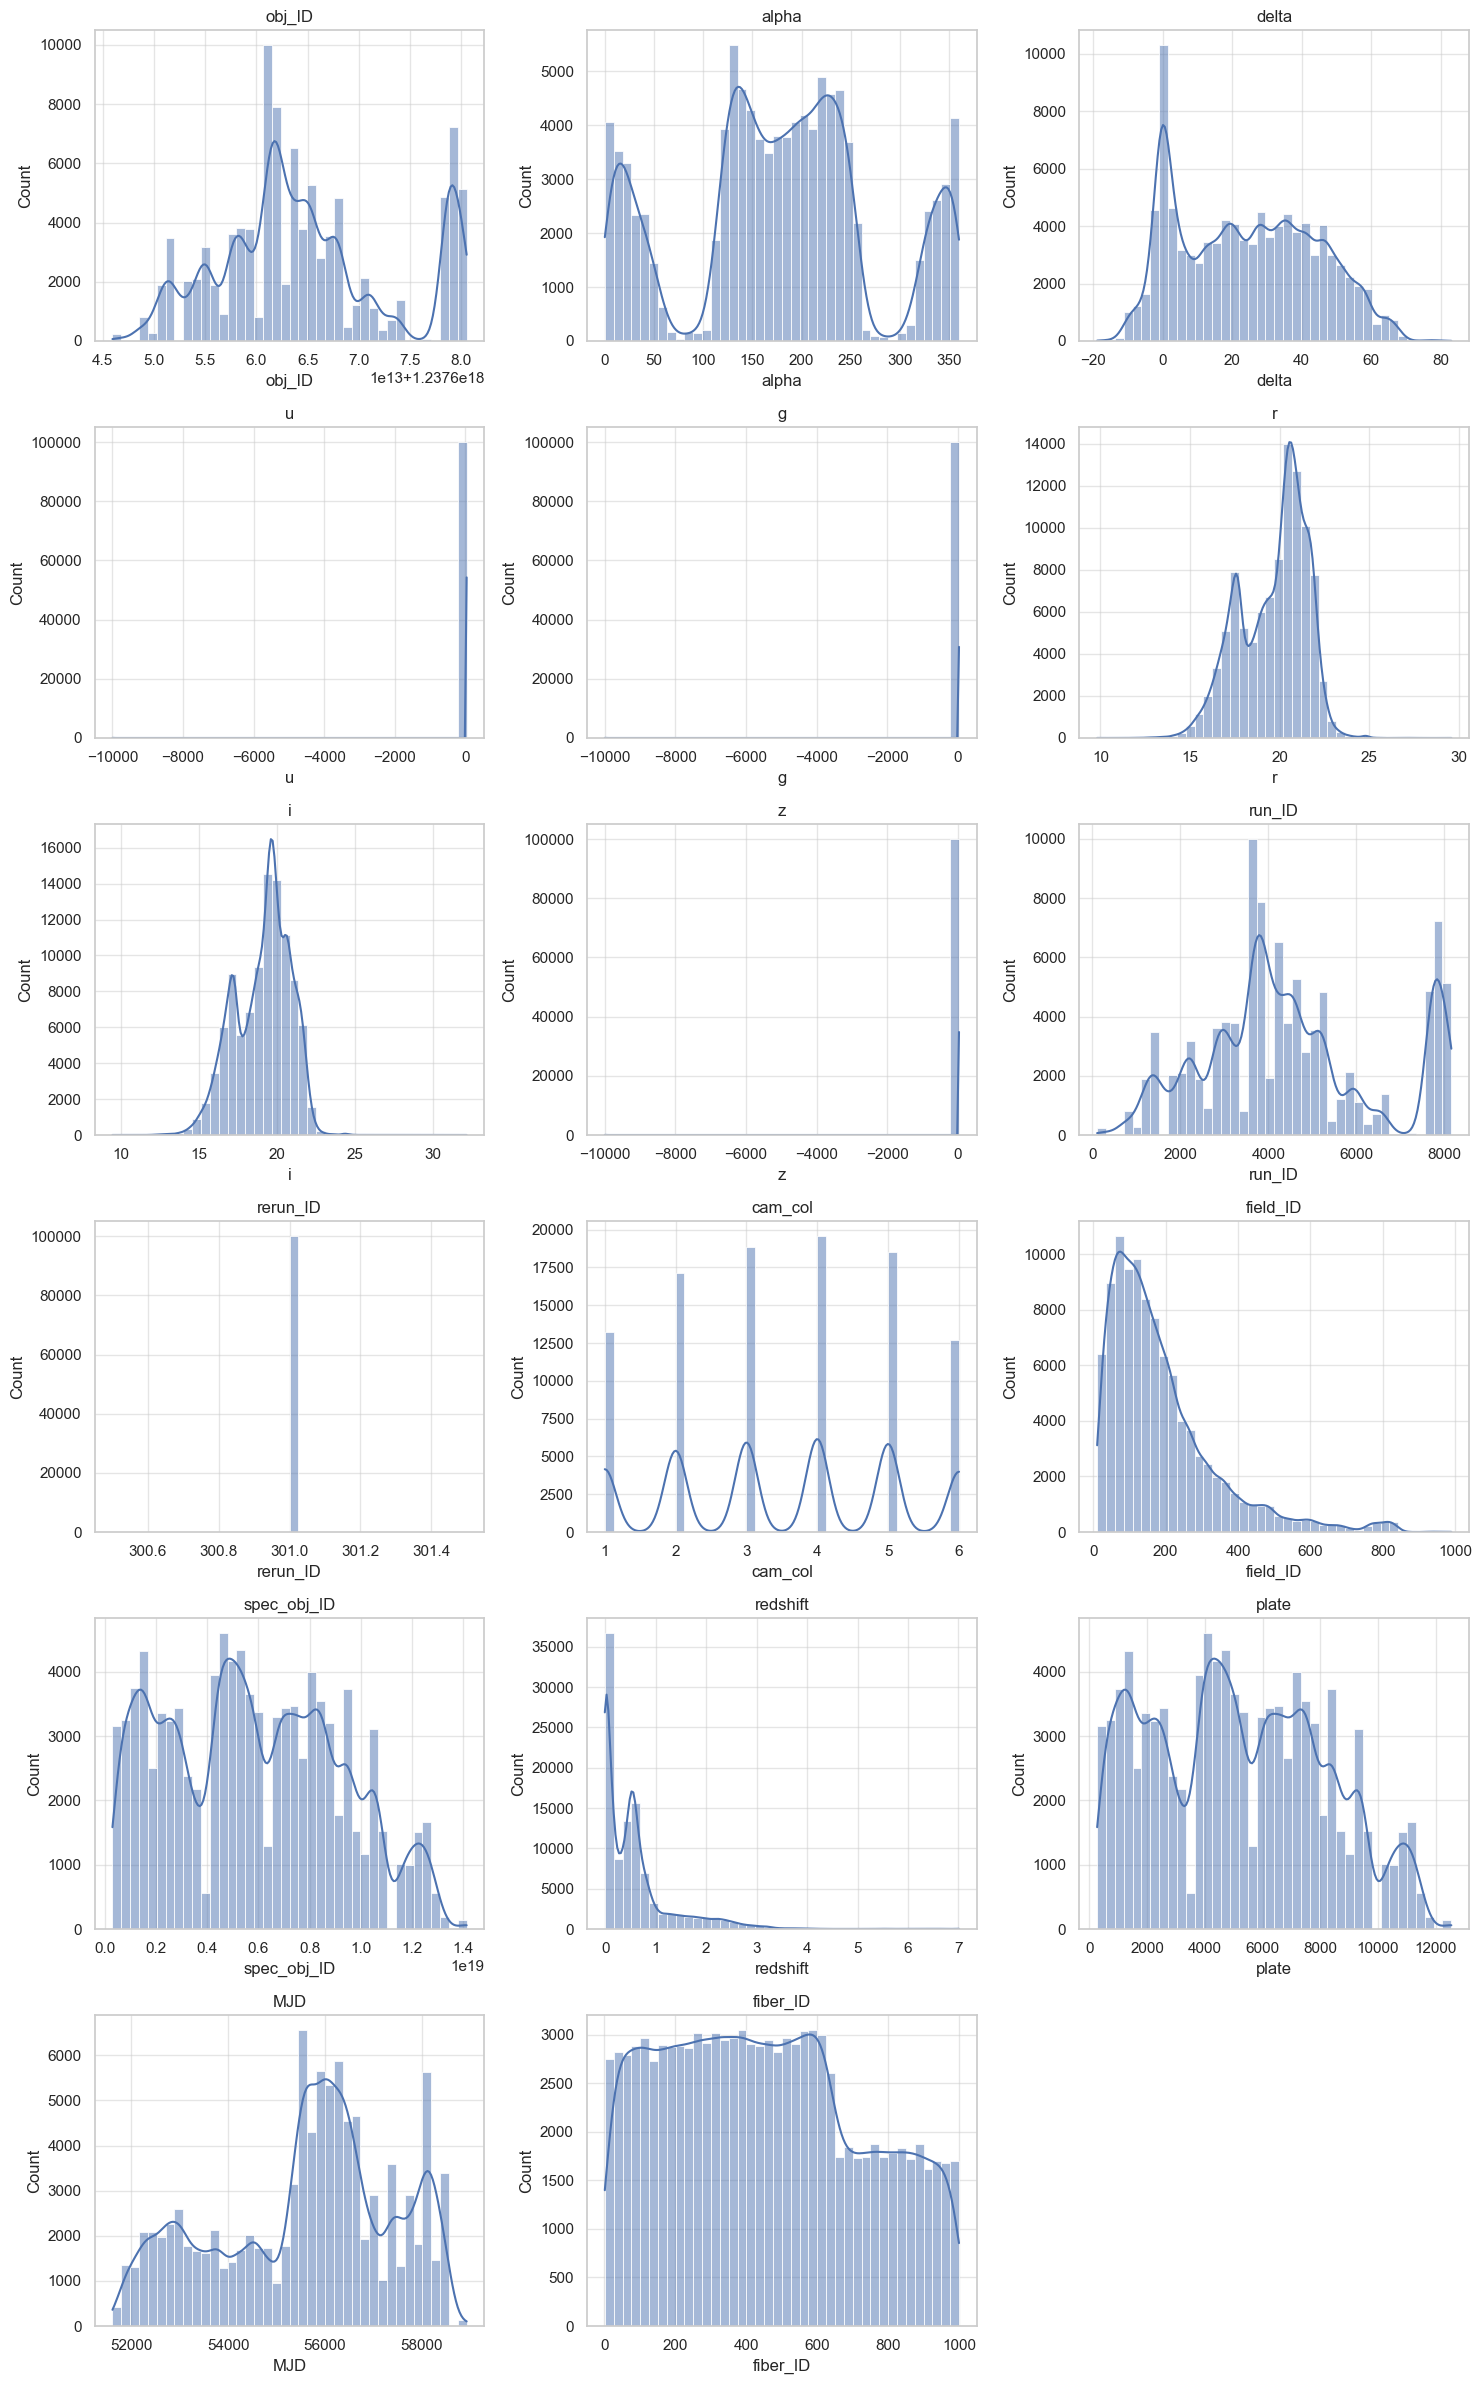

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n_cols, n_rows = 3, int(np.ceil(len(numeric_cols) / 3))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=40)
    ax.set_title(col)
for ax in axes.flatten()[len(numeric_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

Macierz korelacji pokazuje zależności między cechami — pasma fotometryczne są silnie skorelowane.


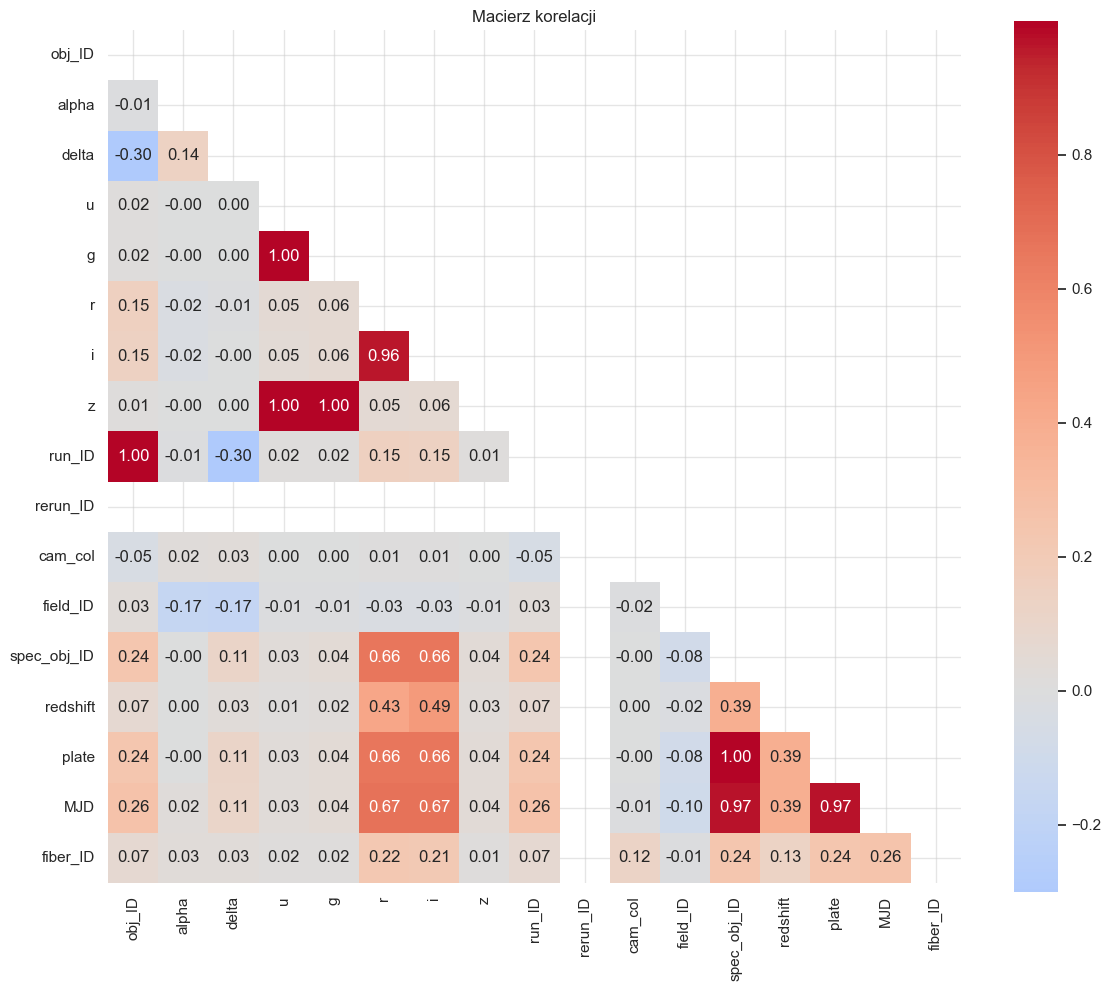

In [8]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Macierz korelacji")
plt.tight_layout()
plt.show()

Podział kolumn na identyfikatory (do usunięcia) i cechy przydatne do klasyfikacji.


In [9]:
existing_ids = [c for c in ID_COLUMNS if c in df.columns]
feature_cols = [c for c in df.columns if c not in existing_ids + [TARGET_COLUMN]]

print("Do usunięcia (ID / metadane):", existing_ids)
print("Cechy do modelu:", feature_cols)

Do usunięcia (ID / metadane): ['obj_ID', 'spec_obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'plate', 'MJD', 'fiber_ID']
Cechy do modelu: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']


Zbiór bez braków, 3 klasy z umiarkowaną nierównowagą. Identyfikatory SDSS nie powinny trafiać do modelu.

## 2. Przygotowanie danych

Kodowanie etykiet, standaryzacja, podział 70/15/15.

Przygotowanie danych: usunięcie ID, kodowanie etykiet, standaryzacja i podział 70/15/15.


In [10]:
df_model = df.drop(columns=existing_ids).copy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_model[TARGET_COLUMN])
class_names = label_encoder.classes_
num_classes = len(class_names)

X = df_model.drop(columns=[TARGET_COLUMN]).values.astype(np.float32)
input_dim = X.shape[1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp,
)

for name, X_s, y_s in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name}: {len(y_s):,} ({len(y_s)/len(y)*100:.1f}%)")

train: 70,000 (70.0%)
val: 15,000 (15.0%)
test: 15,000 (15.0%)


In [11]:
joblib.dump(scaler, ARTIFACTS_DIR / "standard_scaler.joblib")
joblib.dump(label_encoder, ARTIFACTS_DIR / "label_encoder.joblib")
print("Zapisano scaler i label encoder do artifacts/")

Zapisano scaler i label encoder do artifacts/


## 3. Generator modeli i trening


In [12]:
FIXED_HP = {
    "optimizer": "adam", "learning_rate": 0.001, "dropout": 0.0,
    "l2": 0.0, "batch_norm": False, "activation": "relu",
}

def get_optimizer(optimizer_name, learning_rate):
    return keras.optimizers.Adam(learning_rate=learning_rate)

def build_model(hidden_layers, dropout_rate, learning_rate, optimizer_name,
                l2_rate=0.0, batch_norm=False, activation="relu"):
    model = keras.Sequential(name="MLP_classifier")
    model.add(layers.Input(shape=(input_dim,)))
    reg = keras.regularizers.l2(l2_rate) if l2_rate > 0 else None
    for i, units in enumerate(hidden_layers):
        model.add(layers.Dense(units, kernel_regularizer=reg, name=f"dense_{i+1}"))
        if batch_norm:
            model.add(layers.BatchNormalization(name=f"bn_{i+1}"))
        if activation == "relu":
            model.add(layers.Activation("relu", name=f"act_{i+1}"))
        elif activation == "leaky_relu":
            model.add(layers.LeakyReLU(name=f"act_{i+1}"))
        elif activation == "tanh":
            model.add(layers.Activation("tanh", name=f"act_{i+1}"))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate, name=f"dropout_{i+1}"))
    model.add(layers.Dense(num_classes, activation="softmax", name="output"))
    model.compile(optimizer=get_optimizer(optimizer_name, learning_rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def make_experiment(name, block, changed_factor, **overrides):
    cfg = {**FIXED_HP, "name": name, "block": block, "changed_factor": changed_factor, "hidden_layers": []}
    cfg.update(overrides)
    return cfg

def plot_training_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(history.history["loss"]) + 1)
    axes[0].plot(ep, history.history["accuracy"], label="train")
    axes[0].plot(ep, history.history["val_accuracy"], label="val")
    axes[0].set_title(f"{model_name} — accuracy"); axes[0].legend()
    axes[1].plot(ep, history.history["loss"], label="train")
    axes[1].plot(ep, history.history["val_loss"], label="val")
    axes[1].set_title(f"{model_name} — loss"); axes[1].legend()
    plt.tight_layout(); plt.show()

def plot_confusion_matrix(cm, class_names, model_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion matrix — {model_name}"); plt.tight_layout(); plt.show()

def run_experiments(experiments, results, X_train, y_train, X_val, y_val, X_test, y_test,
                    class_names, training_config):
    for exp in experiments:
        print(f"\n[{exp['block']}] {exp['name']} | zmieniany czynnik: {exp['changed_factor']}")
        model = build_model(
            hidden_layers=exp["hidden_layers"], dropout_rate=exp["dropout"],
            l2_rate=exp["l2"], batch_norm=exp["batch_norm"], activation=exp["activation"],
            learning_rate=exp["learning_rate"], optimizer_name=exp["optimizer"],
        )
        early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=training_config["early_stopping_patience"],
                                           restore_best_weights=True, verbose=0)
        start = time.time()
        history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                            epochs=training_config["epochs"], batch_size=training_config["batch_size"],
                            callbacks=[early_stop], verbose=0)
        training_time = time.time() - start
        print(f"  parametry: {model.count_params():,}, czas: {training_time:.1f}s")
        model.summary()
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        metrics = {
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
            "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
            "f1_score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        }
        cm = confusion_matrix(y_test, y_pred)
        print(f"  accuracy={metrics['accuracy']:.4f}  f1={metrics['f1_score']:.4f}")
        print(classification_report(y_test, y_pred, target_names=class_names))
        plot_confusion_matrix(cm, class_names, exp["name"])
        plot_training_curves(history, exp["name"])
        results[exp["name"]] = {
            **exp, "model": model, "history": history, "training_time": training_time,
            "num_params": model.count_params(), "metrics": metrics, "confusion_matrix": cm,
        }

def block_summary(results, block):
    rows = [{"model": n, "f1_score": r["metrics"]["f1_score"], "accuracy": r["metrics"]["accuracy"]}
            for n, r in results.items() if r.get("block") == block]
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("f1_score", ascending=False).reset_index(drop=True)

def build_comparison_table(results):
    rows = []
    for name, r in results.items():
        if "metrics" not in r:
            continue
        rows.append({
            "model": name, "block": r["block"], "zmieniany_czynnik": r["changed_factor"],
            "architektura": str(r["hidden_layers"]), "dropout": r["dropout"], "l2": r["l2"],
            "batch_norm": r["batch_norm"], "activation": r["activation"],
            "accuracy": r["metrics"]["accuracy"], "f1_score": r["metrics"]["f1_score"],
            "czas_treningu_s": round(r["training_time"], 1), "liczba_parametrow": r["num_params"],
        })
    return pd.DataFrame(rows).sort_values("f1_score", ascending=False).reset_index(drop=True)


## 4. Inicjalizacja


In [13]:
TRAINING_CONFIG = {"epochs": 100, "batch_size": 128, "early_stopping_patience": 10}
results = {}


## 5. Blok A — baseline


Punkt odniesienia: regresja logistyczna bez warstw ukrytych.


BLOK A

[A] A_baseline | zmieniany czynnik: brak warstw ukrytych (logistic regression)
  parametry: 27, czas: 54.2s


Model: "MLP_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ output (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (336.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 56 (228.00 B)

  accuracy=0.9455  f1=0.9452
              precision    recall  f1-score   support

      GALAXY       0.96      0.95      0.95      8917
         QSO       0.95      0.87      0.91      2844
        STAR       0.92      0.99      0.95      3239

    accuracy                           0.95     15000
   macro avg       0.94      0.94      0.94     15000
weighted avg       0.95      0.95      0.95     15000



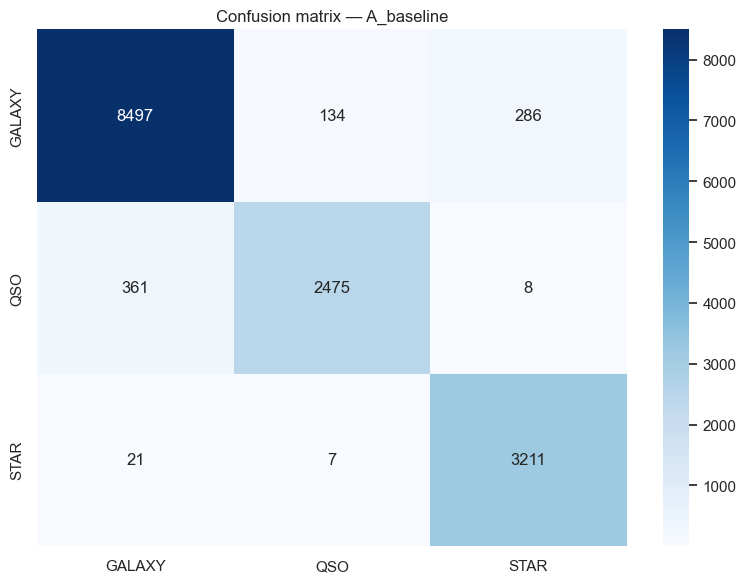

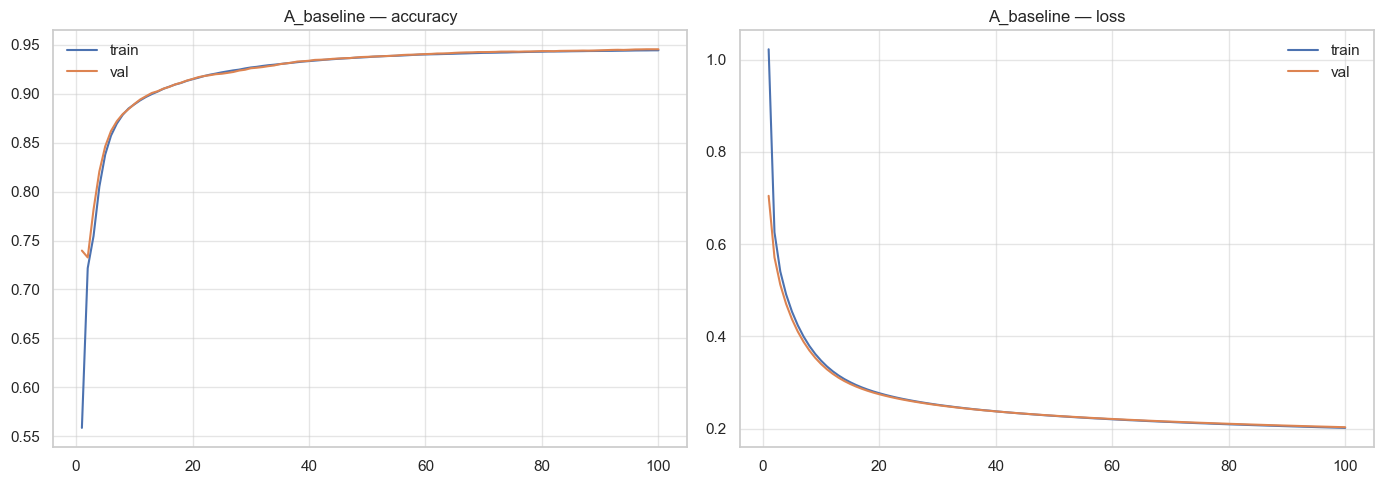

,model,f1_score,accuracy
0,A_baseline,0.94519,0.945533


In [14]:
experiments_a = [
    make_experiment("A_baseline", "A", "brak warstw ukrytych (logistic regression)"),
]
print("BLOK A")
run_experiments(experiments_a, results, X_train, y_train, X_val, y_val, X_test, y_test, class_names, TRAINING_CONFIG)
display(block_summary(results, "A"))


## 6. Blok B — głębokość


BLOK B

[B] B_depth_32 | zmieniany czynnik: hidden_layers
  parametry: 387, czas: 64.8s


Model: "MLP_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,163 (4.55 KB)

 Trainable params: 387 (1.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 776 (3.04 KB)

  accuracy=0.9701  f1=0.9700
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98      8917
         QSO       0.96      0.92      0.94      2844
        STAR       0.96      1.00      0.98      3239

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



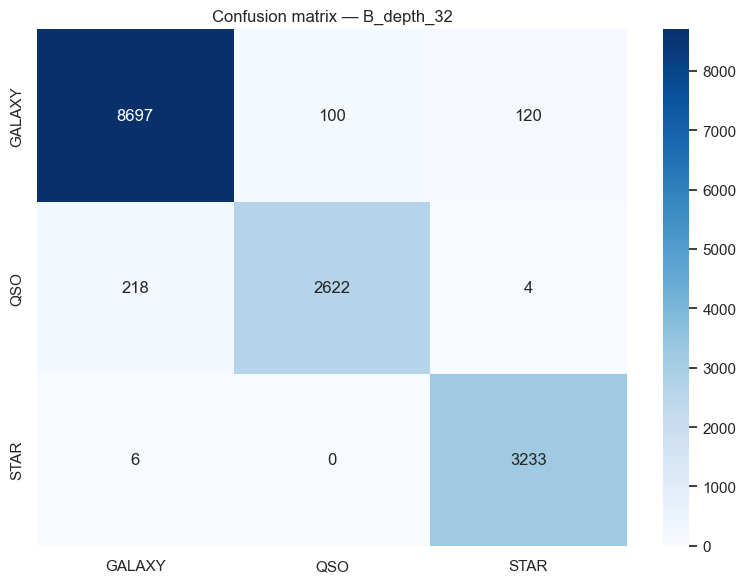

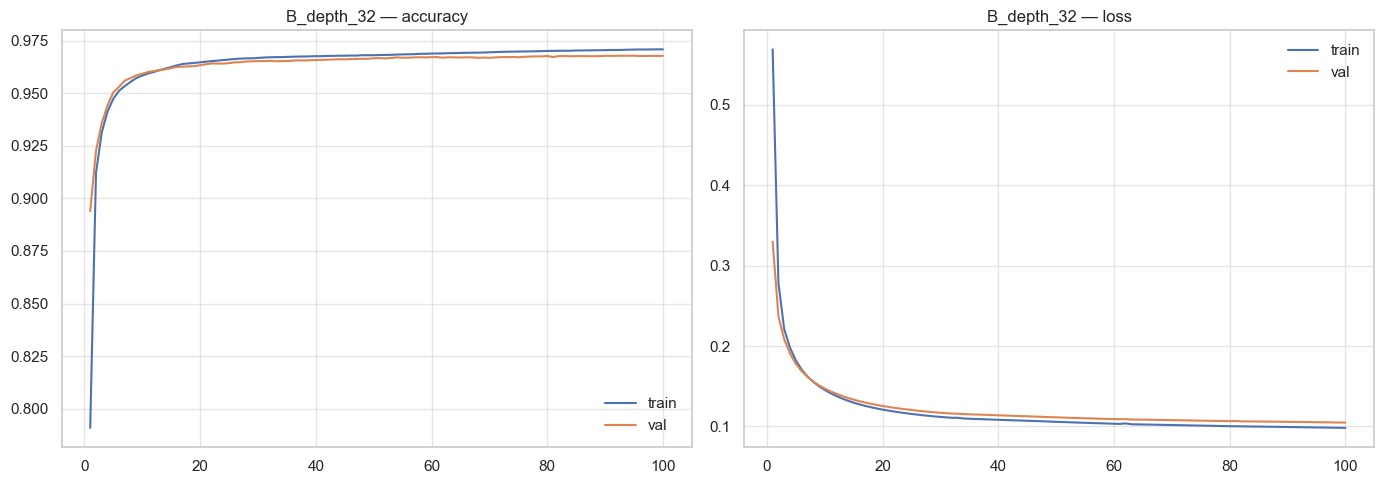


[B] B_depth_64_32 | zmieniany czynnik: hidden_layers
  parametry: 2,755, czas: 64.9s


Model: "MLP_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,267 (32.30 KB)

 Trainable params: 2,755 (10.76 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,512 (21.54 KB)

  accuracy=0.9725  f1=0.9724
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98      8917
         QSO       0.97      0.92      0.94      2844
        STAR       0.97      1.00      0.98      3239

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



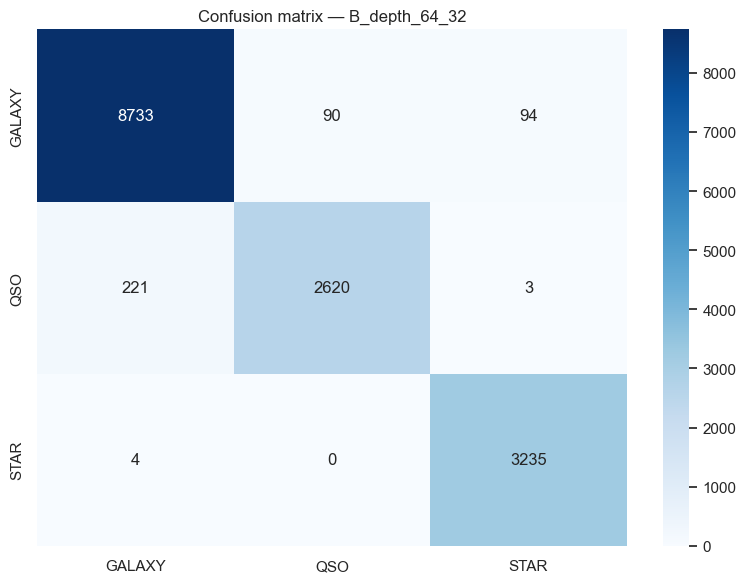

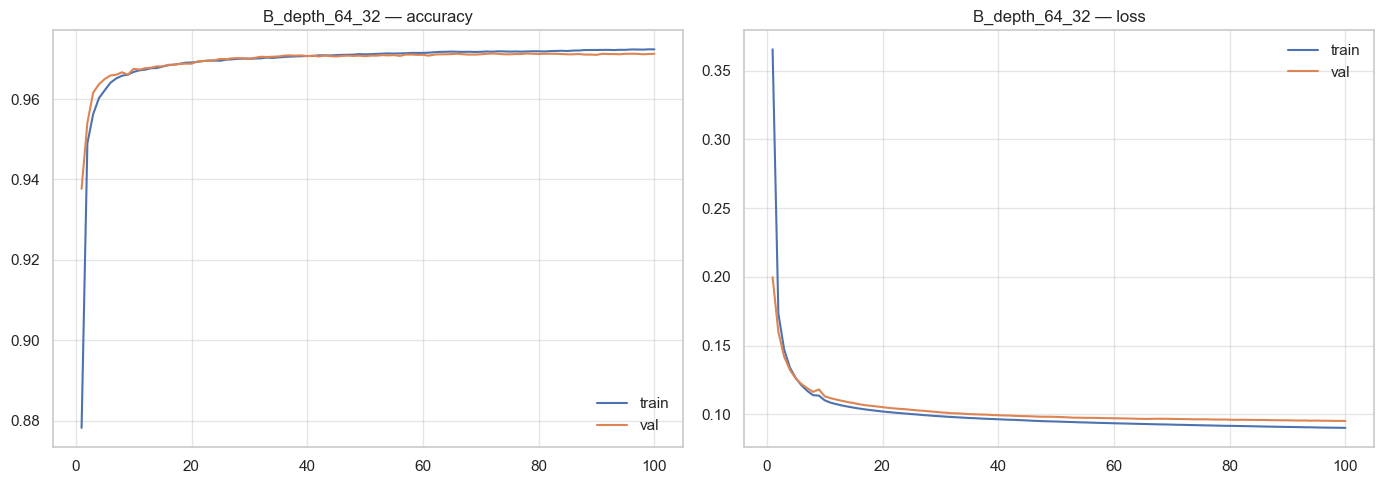


[B] B_depth_128_64_32 | zmieniany czynnik: hidden_layers
  parametry: 11,587, czas: 59.3s


Model: "MLP_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,763 (135.80 KB)

 Trainable params: 11,587 (45.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,176 (90.54 KB)

  accuracy=0.9729  f1=0.9727
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98      8917
         QSO       0.97      0.93      0.95      2844
        STAR       0.97      1.00      0.98      3239

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



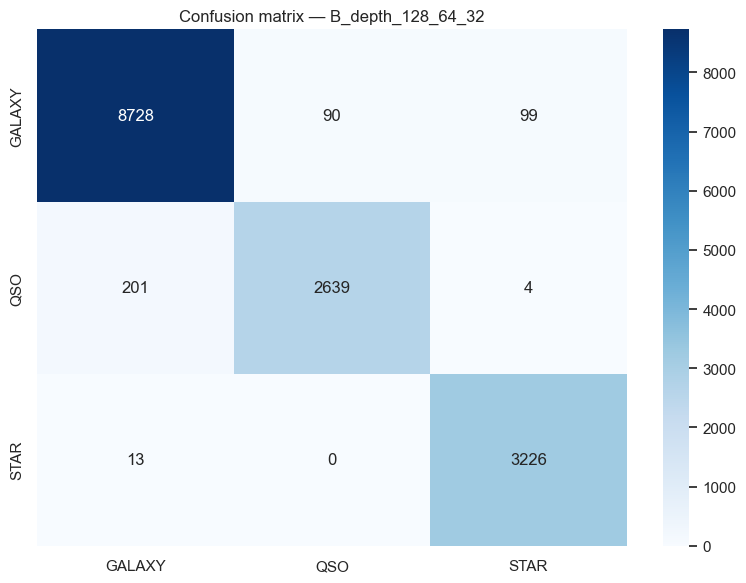

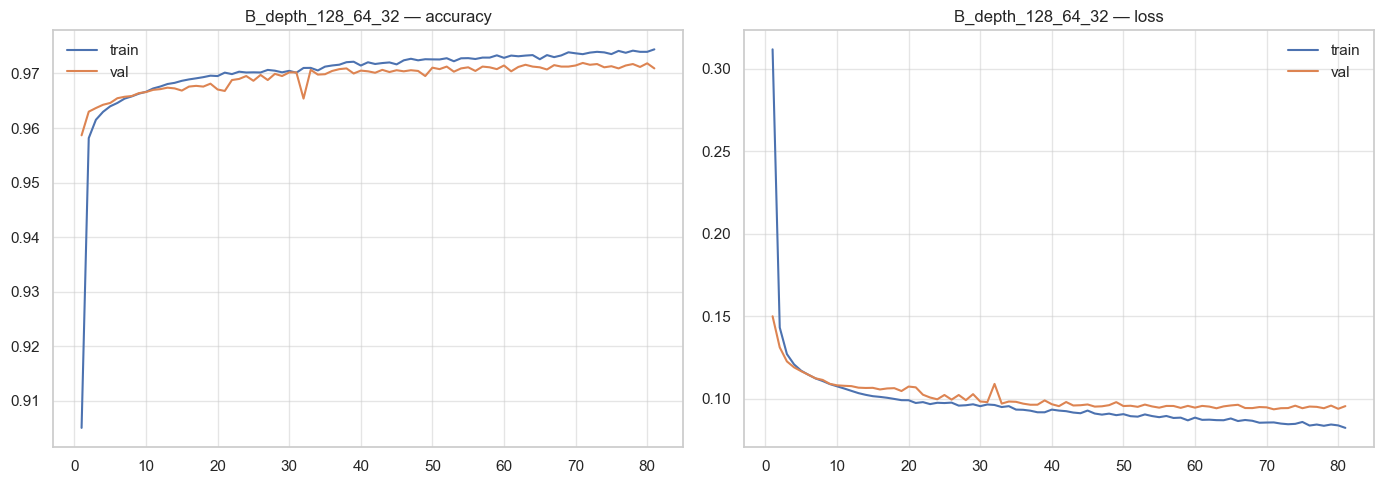

,model,f1_score,accuracy
0,B_depth_128_64_32,0.972736,0.972867
1,B_depth_64_32,0.972360,0.972533
2,B_depth_32,0.969979,0.970133


In [15]:
experiments_b = [
    make_experiment("B_depth_32", "B", "hidden_layers", hidden_layers=[32]),
    make_experiment("B_depth_64_32", "B", "hidden_layers", hidden_layers=[64, 32]),
    make_experiment("B_depth_128_64_32", "B", "hidden_layers", hidden_layers=[128, 64, 32]),
]
print("BLOK B")
run_experiments(experiments_b, results, X_train, y_train, X_val, y_val, X_test, y_test, class_names, TRAINING_CONFIG)
display(block_summary(results, "B"))


## Wybór architektury


In [ ]:

BEST_ARCH = [128, 64, 32]


## 7. Blok C — regularyzacja


BLOK C | arch=[128, 64, 32]

[C] C_dropout_0.2 | zmieniany czynnik: dropout
  parametry: 11,587, czas: 43.4s


Model: "MLP_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,763 (135.80 KB)

 Trainable params: 11,587 (45.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,176 (90.54 KB)

  accuracy=0.9729  f1=0.9727
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98      8917
         QSO       0.96      0.93      0.95      2844
        STAR       0.97      1.00      0.98      3239

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



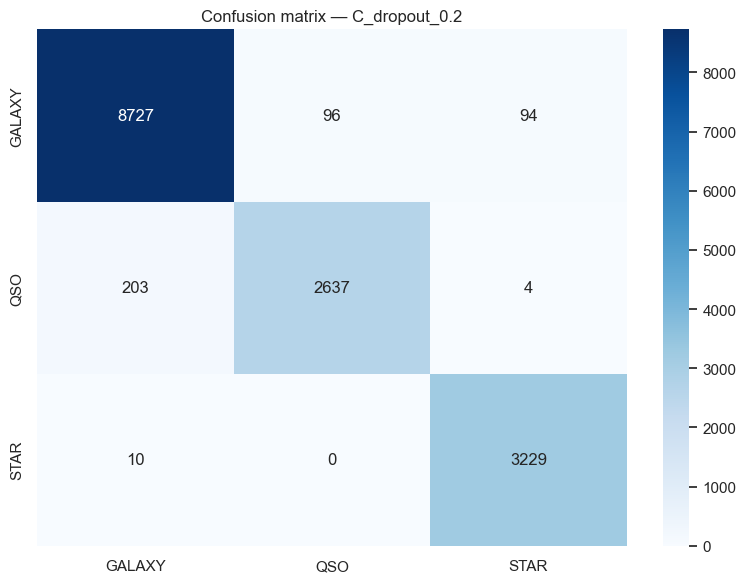

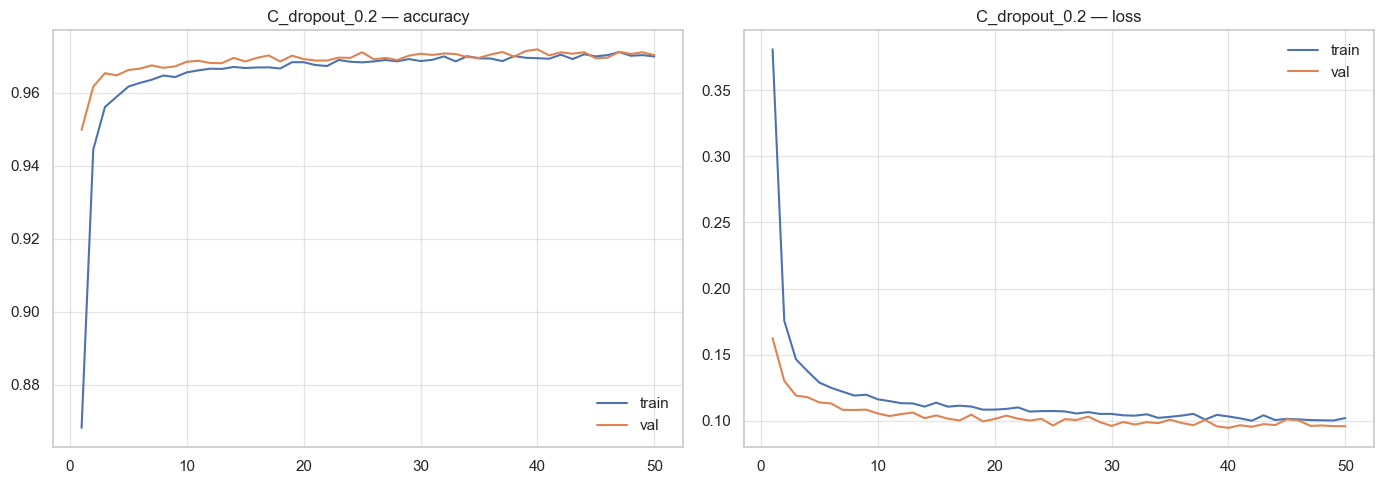


[C] C_dropout_0.4 | zmieniany czynnik: dropout
  parametry: 11,587, czas: 44.1s


Model: "MLP_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,763 (135.80 KB)

 Trainable params: 11,587 (45.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,176 (90.54 KB)

  accuracy=0.9709  f1=0.9707
              precision    recall  f1-score   support

      GALAXY       0.98      0.97      0.98      8917
         QSO       0.96      0.93      0.94      2844
        STAR       0.96      1.00      0.98      3239

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



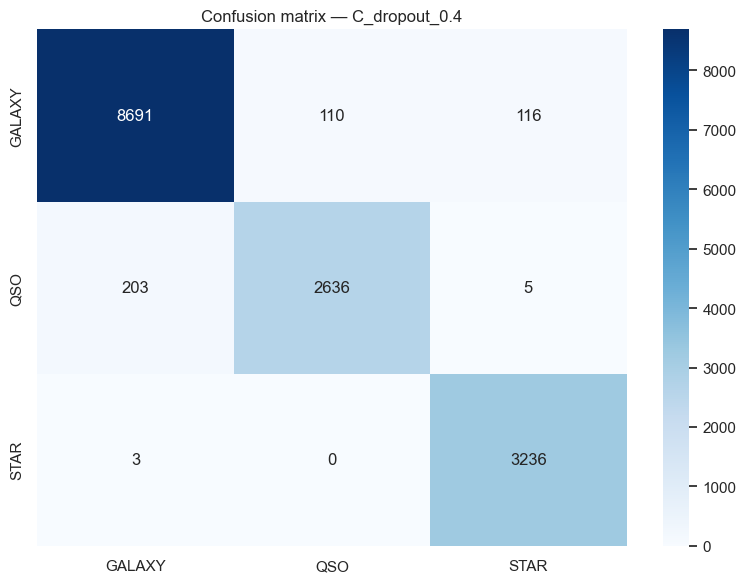

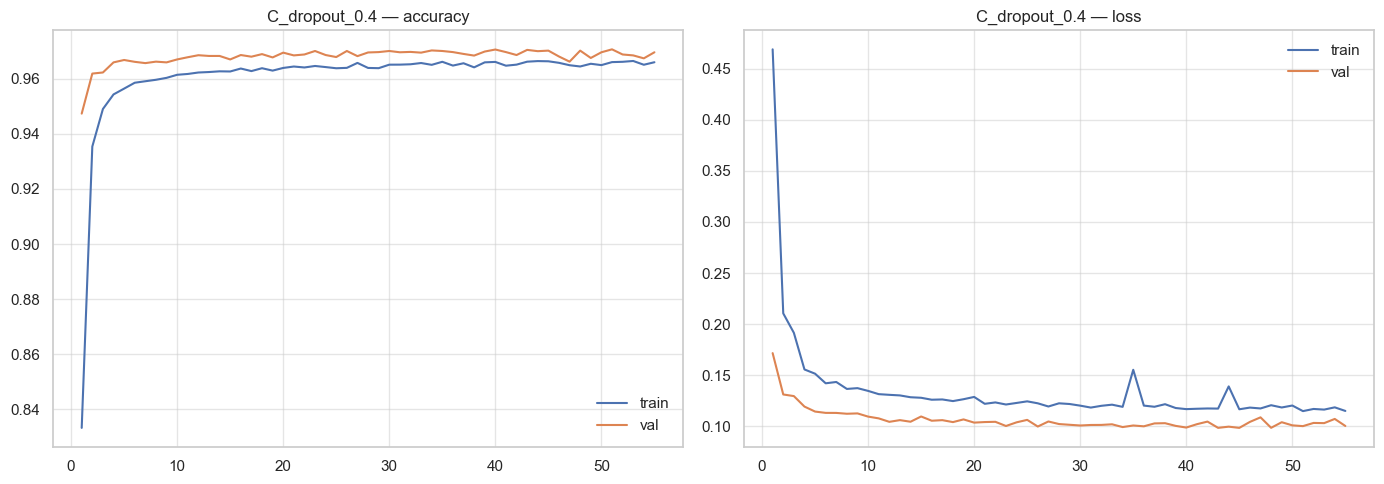


[C] C_l2_1e-4 | zmieniany czynnik: L2
  parametry: 11,587, czas: 62.6s


Model: "MLP_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,763 (135.80 KB)

 Trainable params: 11,587 (45.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,176 (90.54 KB)

  accuracy=0.9718  f1=0.9716
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98      8917
         QSO       0.97      0.92      0.94      2844
        STAR       0.97      0.99      0.98      3239

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



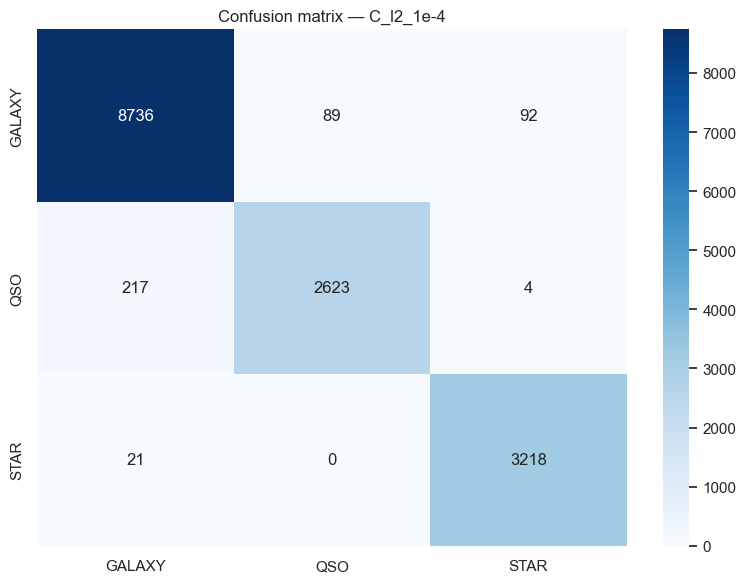

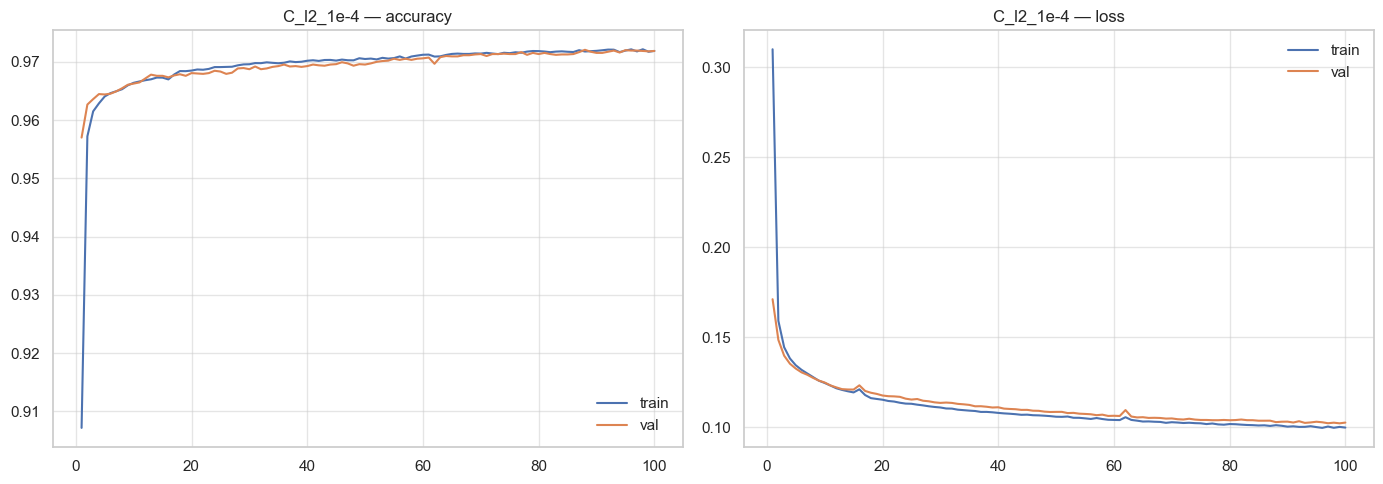

,model,f1_score,accuracy
0,C_dropout_0.2,0.972731,0.972867
1,C_l2_1e-4,0.971644,0.971800
2,C_dropout_0.4,0.970739,0.970867


In [17]:
experiments_c = [
    make_experiment("C_dropout_0.2", "C", "dropout", hidden_layers=BEST_ARCH, dropout=0.2),
    make_experiment("C_dropout_0.4", "C", "dropout", hidden_layers=BEST_ARCH, dropout=0.4),
    make_experiment("C_l2_1e-4", "C", "L2", hidden_layers=BEST_ARCH, l2=1e-4),
]
print(f"BLOK C | arch={BEST_ARCH}")
run_experiments(experiments_c, results, X_train, y_train, X_val, y_val, X_test, y_test, class_names, TRAINING_CONFIG)
display(block_summary(results, "C"))


## 8. Blok D — BatchNorm


BLOK D | arch=[128, 64, 32]

[D] D_batchnorm | zmieniany czynnik: BatchNorm
  parametry: 12,483, czas: 10.1s


Model: "MLP_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,555 (142.80 KB)

 Trainable params: 12,035 (47.01 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 24,072 (94.04 KB)

  accuracy=0.7581  f1=0.6716
              precision    recall  f1-score   support

      GALAXY       0.72      0.98      0.83      8917
         QSO       0.94      0.91      0.93      2844
        STAR       0.77      0.01      0.02      3239

    accuracy                           0.76     15000
   macro avg       0.81      0.63      0.59     15000
weighted avg       0.77      0.76      0.67     15000



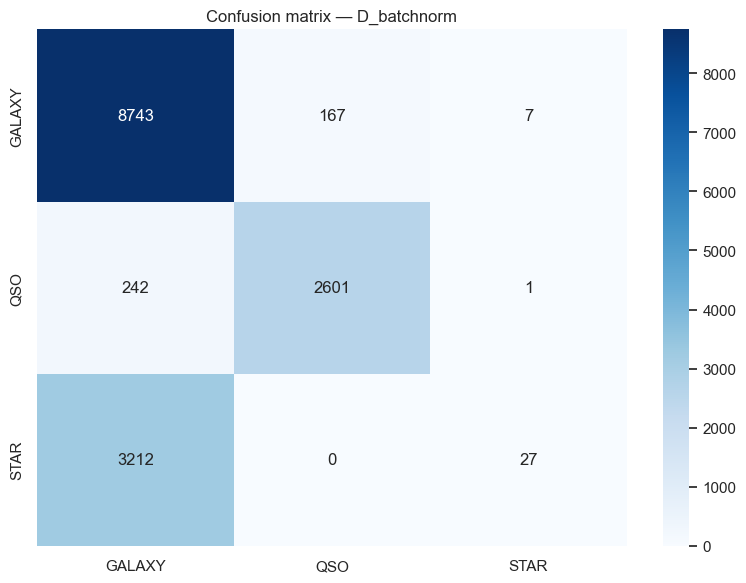

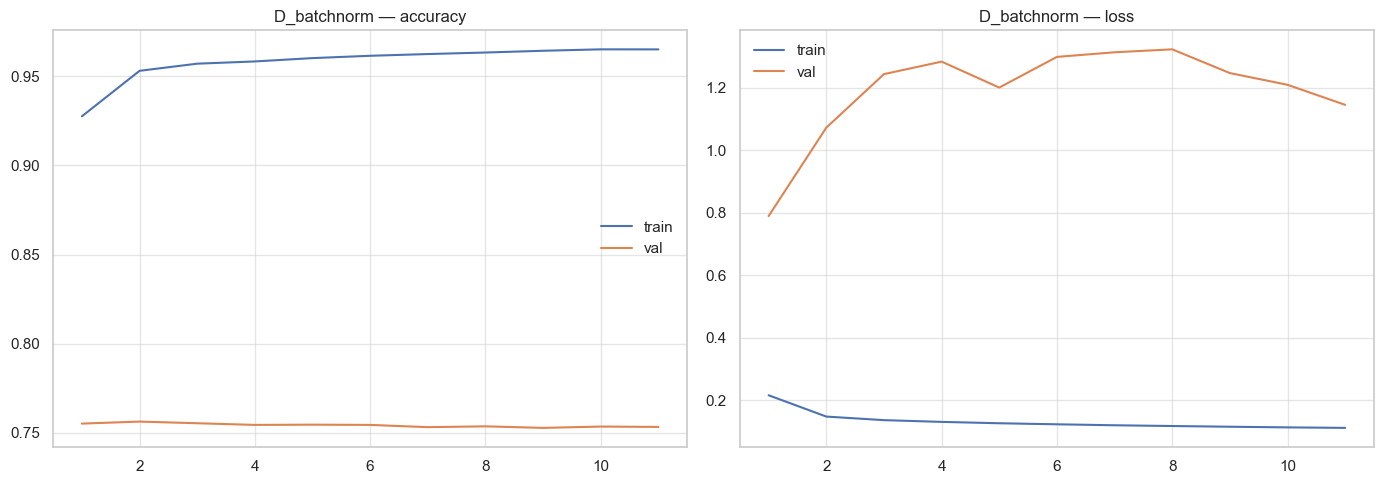

,model,f1_score,accuracy
0,D_batchnorm,0.67163,0.758067


In [18]:
experiments_d = [
    make_experiment("D_batchnorm", "D", "BatchNorm", hidden_layers=BEST_ARCH, batch_norm=True),
]
print(f"BLOK D | arch={BEST_ARCH}")
run_experiments(experiments_d, results, X_train, y_train, X_val, y_val, X_test, y_test, class_names, TRAINING_CONFIG)
display(block_summary(results, "D"))


## 9. Blok E — funkcje aktywacji


BLOK E | arch=[128, 64, 32]

[E] E_relu | zmieniany czynnik: activation
  parametry: 11,587, czas: 55.3s


Model: "MLP_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,763 (135.80 KB)

 Trainable params: 11,587 (45.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,176 (90.54 KB)

  accuracy=0.9728  f1=0.9726
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98      8917
         QSO       0.97      0.92      0.94      2844
        STAR       0.97      1.00      0.98      3239

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



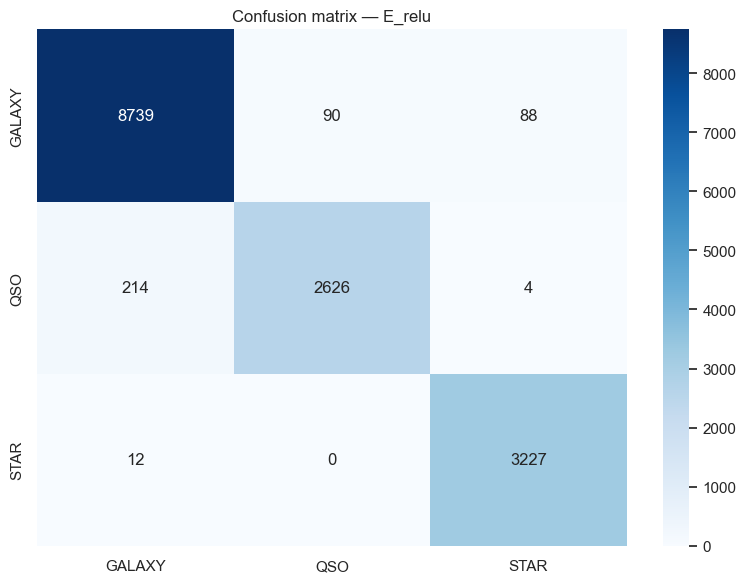

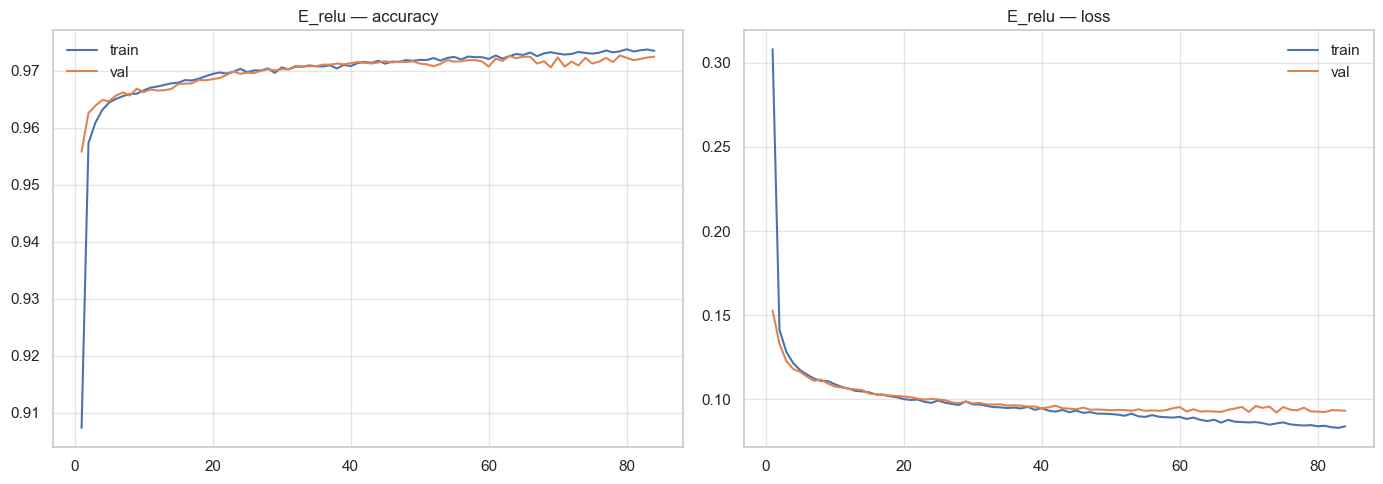


[E] E_leaky_relu | zmieniany czynnik: activation
  parametry: 11,587, czas: 71.4s


Model: "MLP_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (LeakyReLU)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (LeakyReLU)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (LeakyReLU)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,763 (135.80 KB)

 Trainable params: 11,587 (45.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,176 (90.54 KB)

  accuracy=0.9727  f1=0.9725
              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98      8917
         QSO       0.97      0.92      0.94      2844
        STAR       0.97      1.00      0.98      3239

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



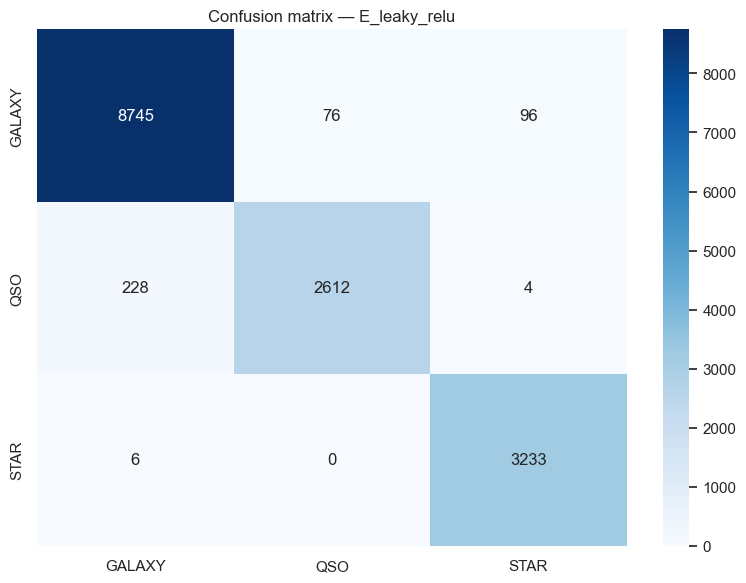

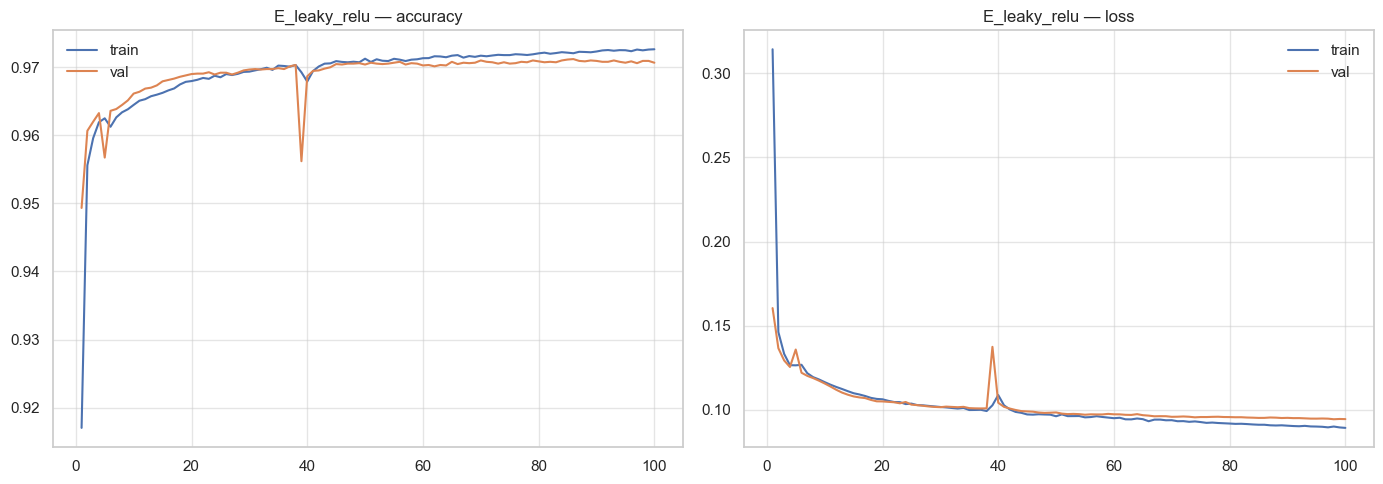


[E] E_tanh | zmieniany czynnik: activation
  parametry: 11,587, czas: 60.7s


Model: "MLP_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,763 (135.80 KB)

 Trainable params: 11,587 (45.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,176 (90.54 KB)

  accuracy=0.9741  f1=0.9739
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98      8917
         QSO       0.97      0.93      0.95      2844
        STAR       0.97      1.00      0.98      3239

    accuracy                           0.97     15000
   macro avg       0.97      0.97      0.97     15000
weighted avg       0.97      0.97      0.97     15000



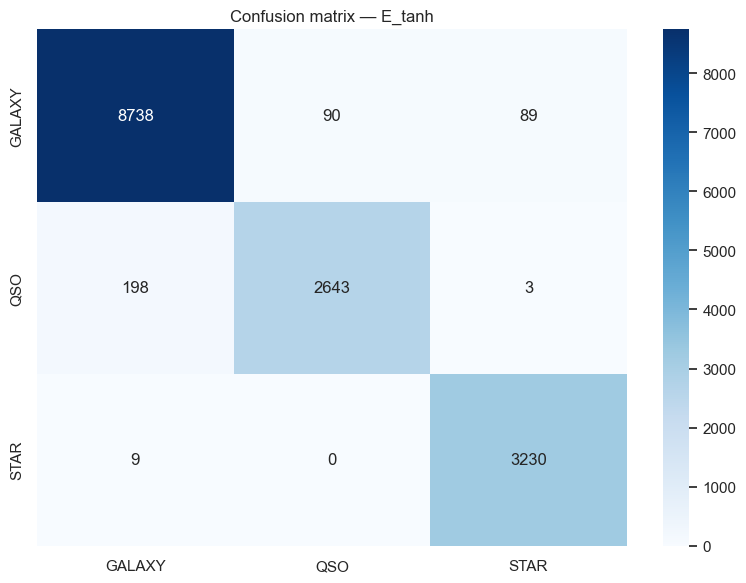

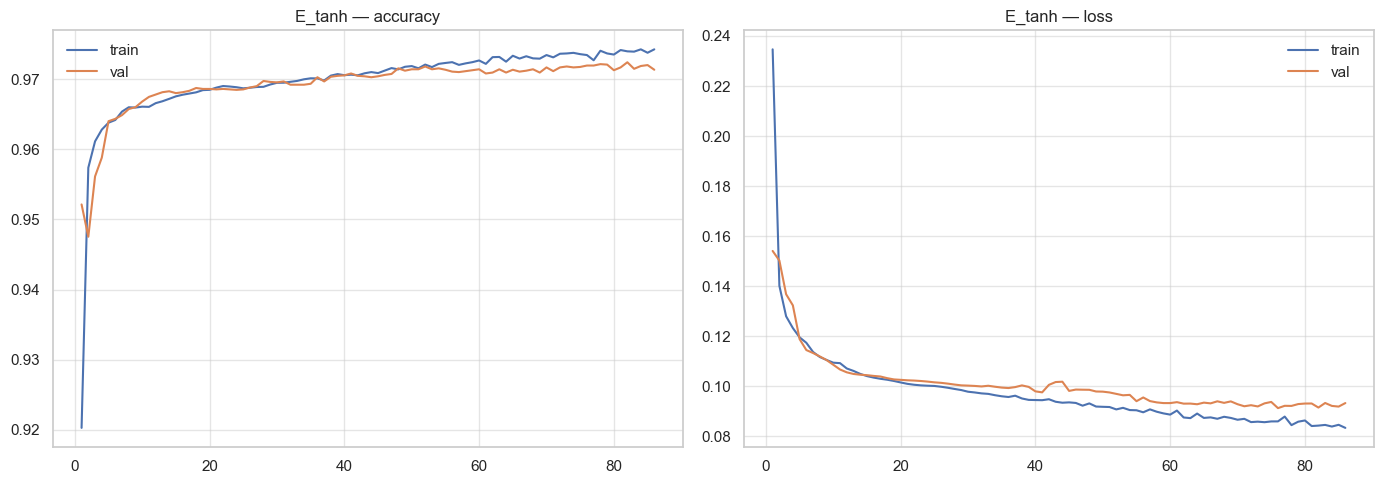

,model,f1_score,accuracy
0,E_tanh,0.973936,0.974067
1,E_relu,0.972642,0.972800
2,E_leaky_relu,0.972475,0.972667


In [19]:
experiments_e = [
    make_experiment("E_relu", "E", "activation", hidden_layers=BEST_ARCH, activation="relu"),
    make_experiment("E_leaky_relu", "E", "activation", hidden_layers=BEST_ARCH, activation="leaky_relu"),
    make_experiment("E_tanh", "E", "activation", hidden_layers=BEST_ARCH, activation="tanh"),
]
print(f"BLOK E | arch={BEST_ARCH}")
run_experiments(experiments_e, results, X_train, y_train, X_val, y_val, X_test, y_test, class_names, TRAINING_CONFIG)
display(block_summary(results, "E"))


## 10. Porównanie wszystkich modeli


In [20]:
display(build_comparison_table(results))


,model,block,zmieniany_czynnik,architektura,dropout,l2,batch_norm,activation,accuracy,f1_score,czas_treningu_s,liczba_parametrow
0,E_tanh,E,activation,"[128, 64, 32]",0.0,0.0000,False,tanh,0.974067,0.973936,60.7,11587
1,B_depth_128_64_32,B,hidden_layers,"[128, 64, 32]",0.0,0.0000,False,relu,0.972867,0.972736,59.3,11587
2,C_dropout_0.2,C,dropout,"[128, 64, 32]",0.2,0.0000,False,relu,0.972867,0.972731,43.4,11587
3,E_relu,E,activation,"[128, 64, 32]",0.0,0.0000,False,relu,0.972800,0.972642,55.3,11587
4,E_leaky_relu,E,activation,"[128, 64, 32]",0.0,0.0000,False,leaky_relu,0.972667,0.972475,71.4,11587
5,B_depth_64_32,B,hidden_layers,"[64, 32]",0.0,0.0000,False,relu,0.972533,0.972360,64.9,2755
6,C_l2_1e-4,C,L2,"[128, 64, 32]",0.0,0.0001,False,relu,0.971800,0.971644,62.6,11587
7,C_dropout_0.4,C,dropout,"[128, 64, 32]",0.4,0.0000,False,relu,0.970867,0.970739,44.1,11587
8,B_depth_32,B,hidden_layers,[32],0.0,0.0000,False,relu,0.970133,0.969979,64.8,387
9,A_baseline,A,brak warstw ukrytych (logistic regression),[],0.0,0.0000,False,relu,0.945533,0.945190,54.2,27
